# EDA - Egyptians Real Estate Fund

This notebook follows the same process as `01_EDA_EGX30.ipynb` and exports the final engineered dataset.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_csv("cleaned_data/egyptians_real_estate_fund.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date').sort_index()

df.shape, df.head()

((697, 6),
             price  open  high   low      vol  change_pct
 date                                                    
 2020-04-12   8.50  8.45  8.50  8.45  0.05584        0.00
 2020-04-13   8.50  8.50  8.50  8.50  0.00060        0.00
 2020-04-16   8.79  8.50  9.00  8.50  0.01000        3.41
 2020-04-21   9.00  9.00  9.00  9.00  0.00437        2.39
 2020-04-27   9.00  9.55  9.55  9.55  0.00010        0.00)

In [21]:
print(df.info())
print(df.isnull().sum())

# same handling as EGX30 notebook for volume
if 'vol' in df.columns:
    df['vol'] = df['vol'].fillna(df['vol'].mean())

<class 'pandas.DataFrame'>
DatetimeIndex: 697 entries, 2020-04-12 to 2026-04-30
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   price       697 non-null    float64
 1   open        697 non-null    float64
 2   high        697 non-null    float64
 3   low         697 non-null    float64
 4   vol         658 non-null    float64
 5   change_pct  697 non-null    float64
dtypes: float64(6)
memory usage: 38.1 KB
None
price          0
open           0
high           0
low            0
vol           39
change_pct     0
dtype: int64


In [22]:
# Feature engineering (same structure as 01_EDA_EGX30.ipynb)
df['return'] = df['price'].pct_change()
df['return_lag1'] = df['return'].shift(1)
df['return_lag2'] = df['return'].shift(2)

df['ma_20'] = df['price'].rolling(20).mean()
df['volatility_20'] = df['return'].rolling(20).std()
df['ma_5'] = df['price'].rolling(5).mean()

df['dist_to_ma5'] = (df['price'] / df['ma_5']) - 1
df['dist_to_ma20'] = (df['price'] / df['ma_20']) - 1

ema_12 = df['price'].ewm(span=12, adjust=False).mean()
ema_26 = df['price'].ewm(span=26, adjust=False).mean()
df['macd'] = ema_12 - ema_26
df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
df['macd_hist'] = df['macd'] - df['macd_signal']

window = 20
sma_20 = df['price'].rolling(window=window).mean()
std_20 = df['price'].rolling(window=window).std()
upper_band = sma_20 + (std_20 * 2)
lower_band = sma_20 - (std_20 * 2)
df['bb_pb'] = (df['price'] - lower_band) / (upper_band - lower_band)
df['bb_bandwidth'] = (upper_band - lower_band) / sma_20

delta = df['price'].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = (-delta.clip(upper=0)).rolling(14).mean()
df['rsi'] = 100 - (100 / (1 + gain / loss))

threshold = 0.005
future_return = df['return'].shift(-1)
df['label'] = (future_return > threshold).astype(int)

df = df.dropna()

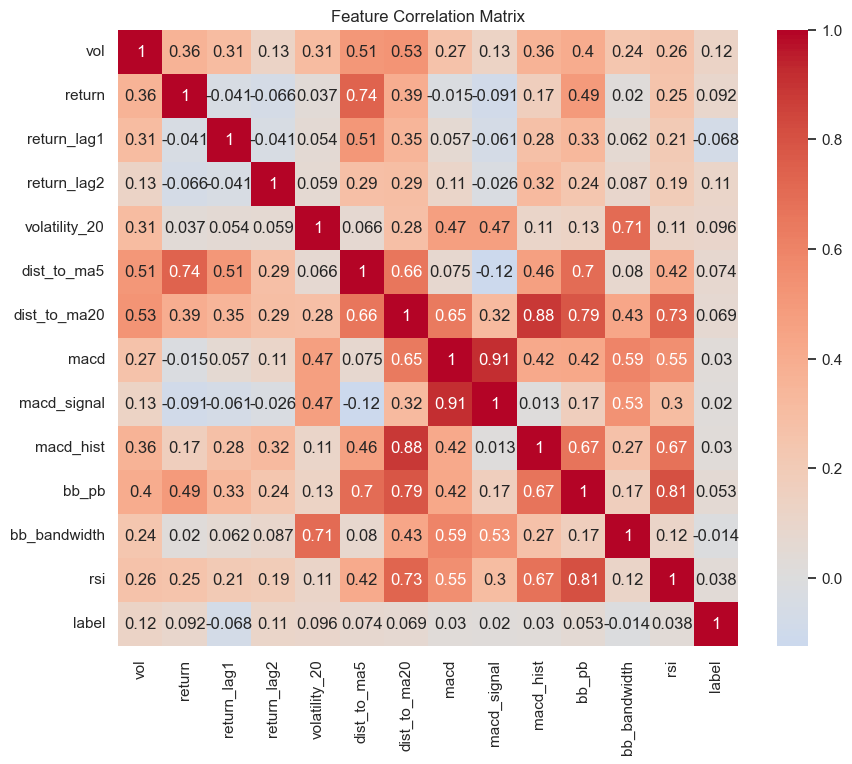

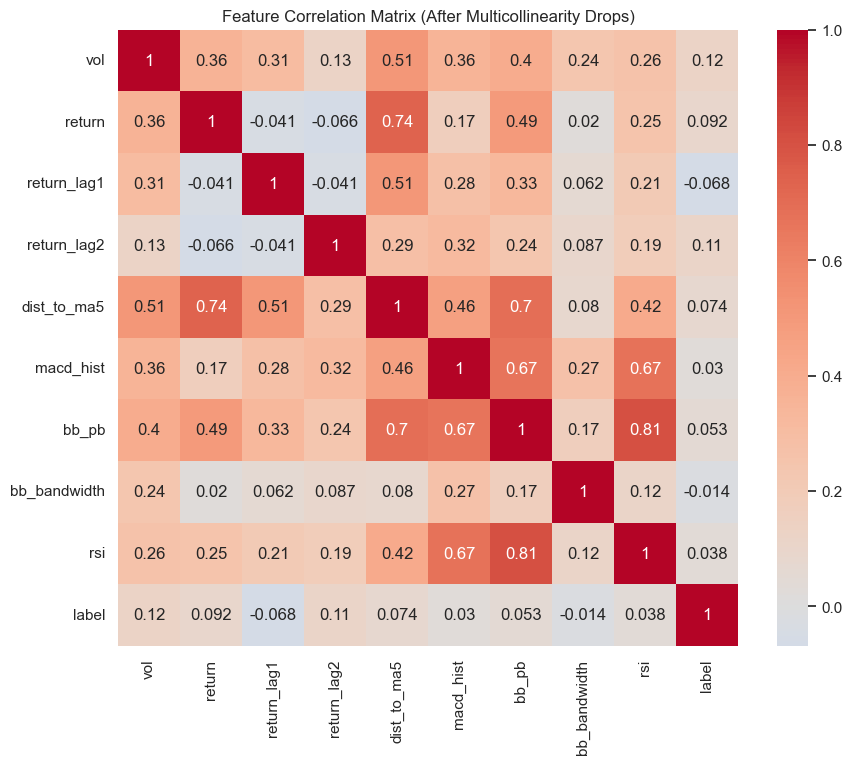

In [23]:
# Match the same column dropping flow used in EGX30 notebook
for col in ['price', 'ma_5', 'ma_20', 'open', 'high', 'low', 'change_pct']:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

for col in ['dist_to_ma20', 'macd', 'macd_signal', 'volatility_20']:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix (After Multicollinearity Drops)')
plt.show()

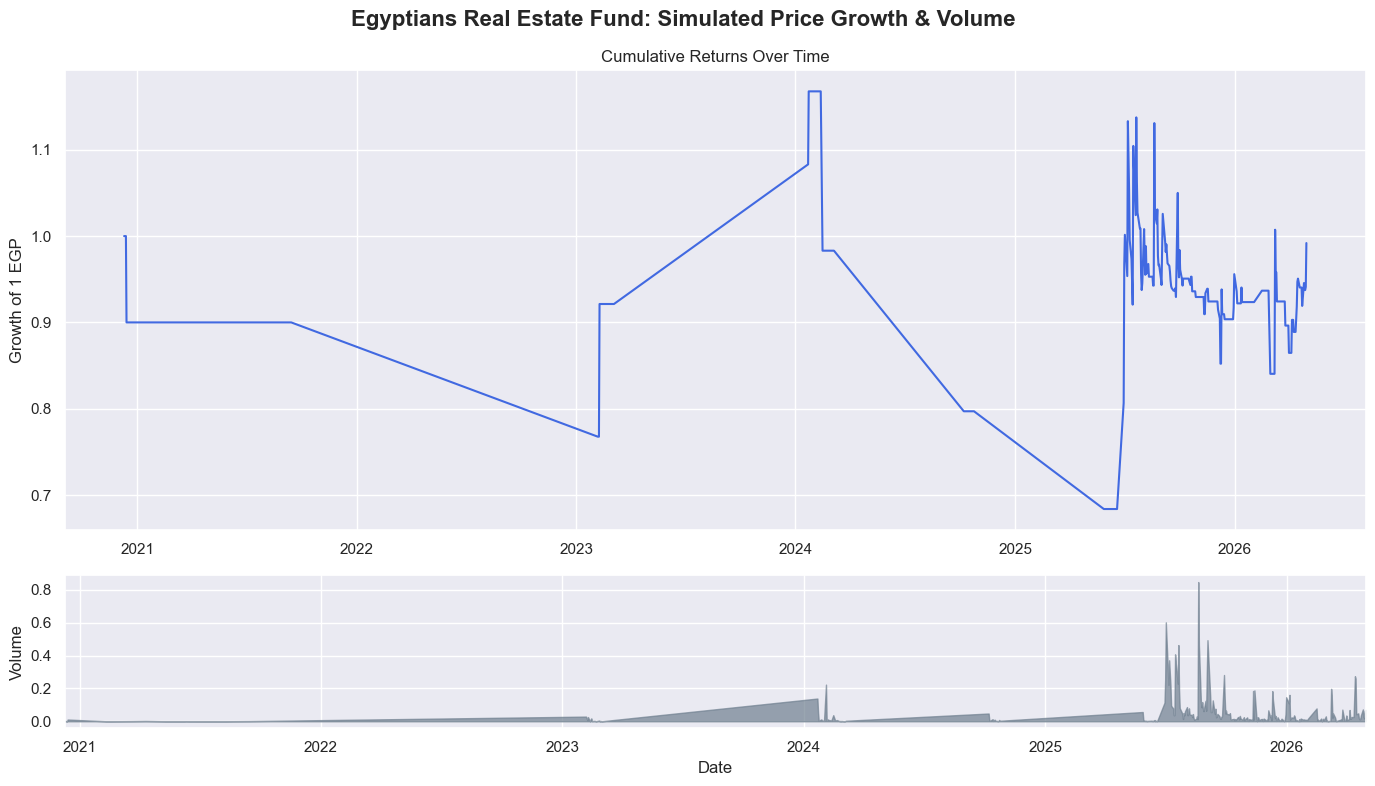

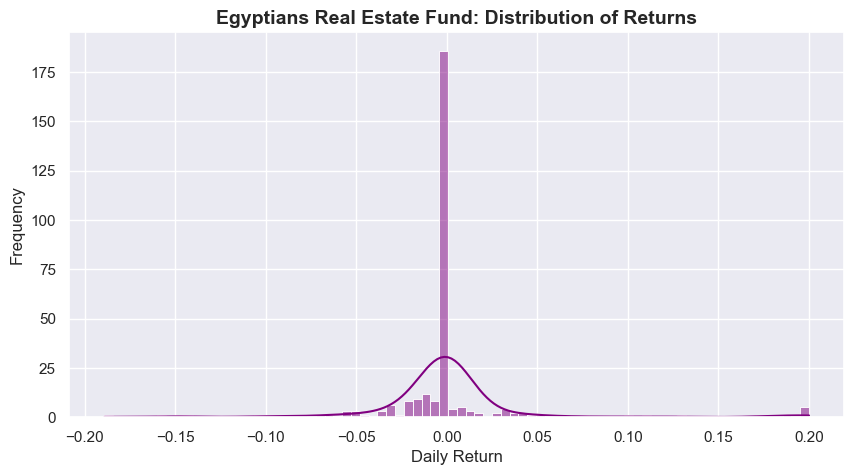

C:\Users\moata\AppData\Local\Temp\ipykernel_28376\1388762919.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='label', palette=['#ff6b6b', '#1dd1a1'])


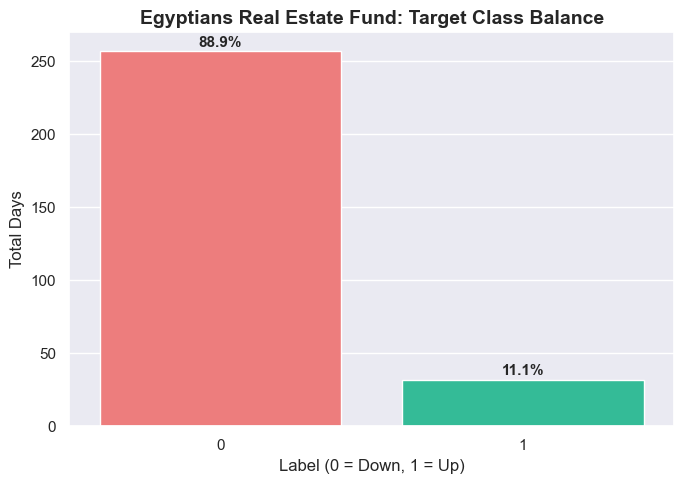

In [24]:
asset_name = "Egyptians Real Estate Fund"
sns.set_theme(style="darkgrid", palette="muted")

cum_return = (1 + df['return']).cumprod()

# Macro trend + volume
if 'vol' in df.columns:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})
    fig.suptitle(f"{asset_name}: Simulated Price Growth & Volume", fontsize=16, fontweight='bold')

    axes[0].plot(df.index, cum_return, color='royalblue', linewidth=1.5)
    axes[0].set_ylabel("Growth of 1 EGP")
    axes[0].set_title("Cumulative Returns Over Time")

    axes[1].fill_between(df.index, df['vol'], color='slategray', alpha=0.7)
    axes[1].set_ylabel("Volume")
    axes[1].set_xlabel("Date")
    axes[1].margins(x=0)
else:
    fig, ax = plt.subplots(figsize=(14, 5))
    fig.suptitle(f"{asset_name}: Simulated Price Growth (No Volume Data)", fontsize=16, fontweight='bold')
    ax.plot(df.index, cum_return, color='royalblue', linewidth=1.5)
    ax.set_ylabel("Growth of 1 EGP")

plt.tight_layout()
plt.show()

# Return distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['return'], kde=True, bins=80, color='purple')
plt.title(f"{asset_name}: Distribution of Returns", fontsize=14, fontweight='bold')
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

# Class balance
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='label', palette=['#ff6b6b', '#1dd1a1'])
plt.title(f"{asset_name}: Target Class Balance", fontsize=14, fontweight='bold')
plt.xlabel("Label (0 = Down, 1 = Up)")
plt.ylabel("Total Days")

total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + (total * 0.01)
    ax.annotate(percentage, (x, y), ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

C:\Users\moata\AppData\Local\Temp\ipykernel_28376\3167951677.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='label', y=feature, ax=axes[i], palette=['#ff6b6b', '#1dd1a1'])
C:\Users\moata\AppData\Local\Temp\ipykernel_28376\3167951677.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='label', y=feature, ax=axes[i], palette=['#ff6b6b', '#1dd1a1'])
C:\Users\moata\AppData\Local\Temp\ipykernel_28376\3167951677.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='label', y=feature, ax=axes[i], palett

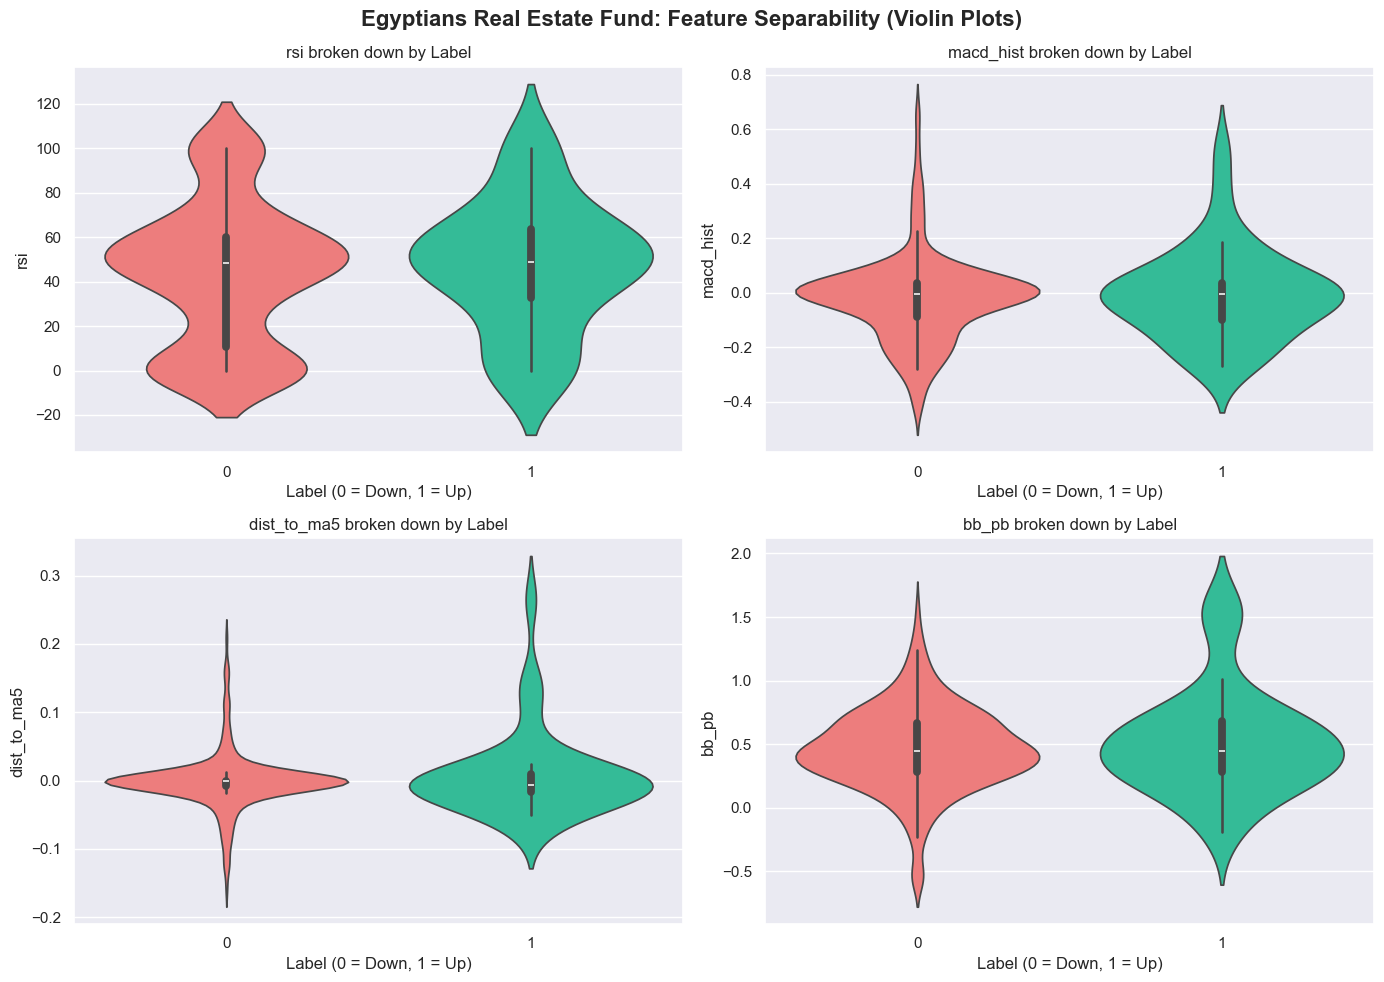

In [25]:
# Feature separability (same style)
features = ['rsi', 'macd_hist', 'dist_to_ma5', 'bb_pb']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"{asset_name}: Feature Separability (Violin Plots)", fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.violinplot(data=df, x='label', y=feature, ax=axes[i], palette=['#ff6b6b', '#1dd1a1'])
    axes[i].set_title(f"{feature} broken down by Label")
    axes[i].set_xlabel("Label (0 = Down, 1 = Up)")

plt.tight_layout()
plt.show()

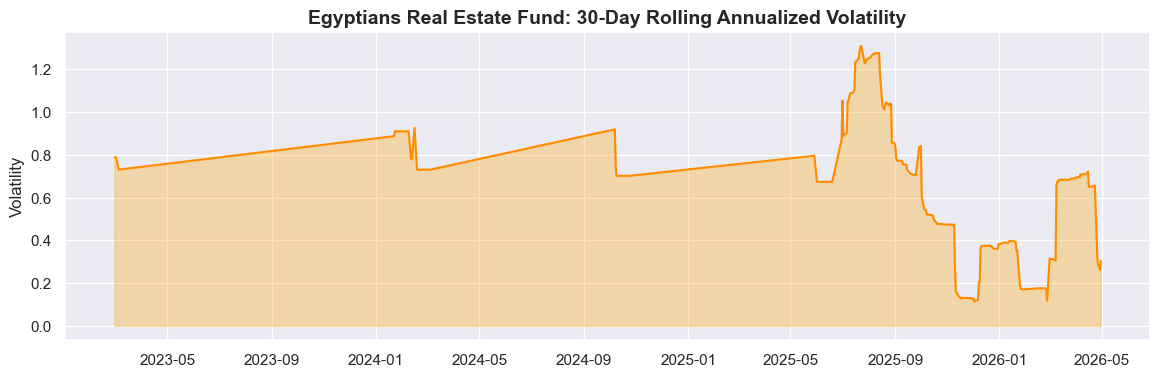

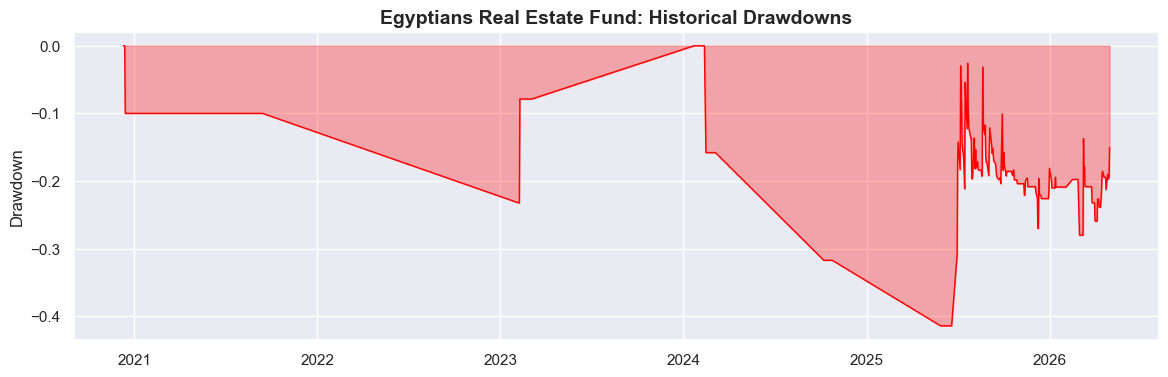

In [26]:
# Additional risk diagnostics used in other notebooks
df['rolling_volatility'] = df['return'].rolling(window=30).std() * np.sqrt(252)

plt.figure(figsize=(14, 4))
plt.plot(df.index, df['rolling_volatility'], color='darkorange', linewidth=1.5)
plt.title(f"{asset_name}: 30-Day Rolling Annualized Volatility", fontsize=14, fontweight='bold')
plt.ylabel("Volatility")
plt.fill_between(df.index, df['rolling_volatility'], alpha=0.3, color='orange')
plt.show()

running_max = cum_return.cummax()
drawdown = (cum_return - running_max) / running_max

plt.figure(figsize=(14, 4))
plt.plot(df.index, drawdown, color='red', linewidth=1)
plt.fill_between(df.index, drawdown, 0, color='red', alpha=0.3)
plt.title(f"{asset_name}: Historical Drawdowns", fontsize=14, fontweight='bold')
plt.ylabel("Drawdown")
plt.show()

In [27]:
# Final export
df.to_csv('final_data/final_egyptians_real_estate_fund.csv')
df.head()

,vol,return,return_lag1,return_lag2,dist_to_ma5,macd_hist,bb_pb,bb_bandwidth,rsi,label,rolling_volatility
date,,,,,,,,,,,
2020-12-10,0.00300,0.000000,0.000000,0.000000,0.000000,0.113954,0.734351,0.708289,100.000000,0,NaN
2020-12-13,0.00005,0.000000,0.000000,0.000000,0.000000,0.059605,0.713721,0.659797,100.000000,0,NaN
2020-12-14,0.01060,-0.099927,0.000000,0.000000,-0.081571,-0.075325,0.520423,0.602909,69.160998,0,NaN
2021-02-08,0.00050,0.000000,-0.099927,0.000000,-0.062452,-0.166723,0.497981,0.545209,65.743073,0,NaN
2021-02-10,0.00012,0.000000,0.000000,-0.099927,-0.042520,-0.225666,0.470374,0.478084,57.763975,0,NaN
